<a href="https://colab.research.google.com/github/tamyressilvazz/machine-learning-p06/blob/main/exercicio_Detec%C3%A7%C3%A3o_de_anomalias_V2_iForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install --upgrade pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('/content/drive/My Drive/datasets/statlog-heart-dataset.csv')

X = df.drop(columns=['class'])

X.head()

median_values = X.median()

print("Median values for each attribute:")
print(median_values)

Median values for each attribute:
age                      55.0
sex                       1.0
chest                     3.0
pressure                130.0
cholestoral             245.0
bloodsugar                0.0
electrocardiographic      2.0
heartRate               153.5
exInducedAngina           0.0
oldpeak                   0.8
slope                     2.0
numMajorVessels           0.0
thal                      3.0
dtype: float64


In [ ]:
from pyod.models.iforest import IForest
from pyod.utils.data import evaluate_print
from pyod.utils.example import visualize

clf_name = 'IForest'
clf = IForest()
clf.fit(X)

 # get the prediction labels and outlier scores of the training data
y_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)
y_scores = clf.decision_scores_  # raw outlier scores

X_out = X[y_pred==1]

X_out

,age,sex,chest,pressure,cholestoral,bloodsugar,electrocardiographic,heartRate,exInducedAngina,oldpeak,slope,numMajorVessels,thal
5,63,0,4,150,407,0,2,154,0,4.0,2,3,7
21,66,1,2,160,246,0,0,120,1,0.0,2,3,6
44,57,1,4,165,289,1,2,124,0,1.0,2,3,7
49,55,0,4,180,327,0,1,117,1,3.4,2,0,3
52,56,0,4,200,288,1,2,133,1,4.0,3,2,7
71,66,0,4,178,228,1,0,165,1,1.0,2,2,7
72,38,1,1,120,231,0,0,182,1,3.8,2,0,7
78,62,0,4,138,294,1,0,106,0,1.9,2,3,3
88,77,1,4,125,304,0,2,162,1,0.0,1,3,3
98,63,1,4,130,330,1,2,132,1,1.8,1,3,7


**Histograma das variáveis**

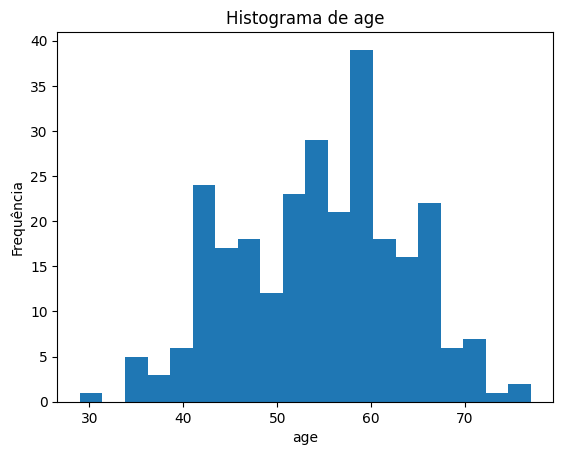

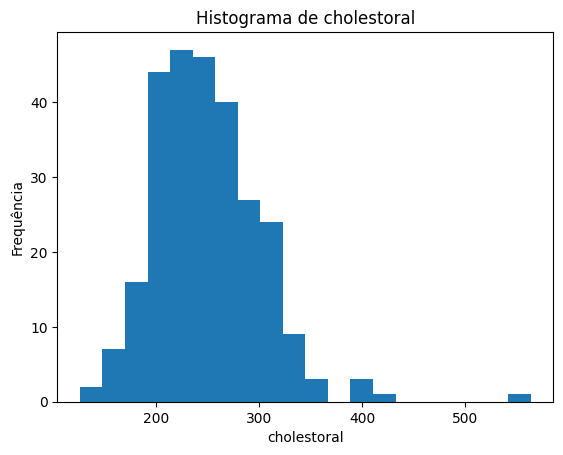

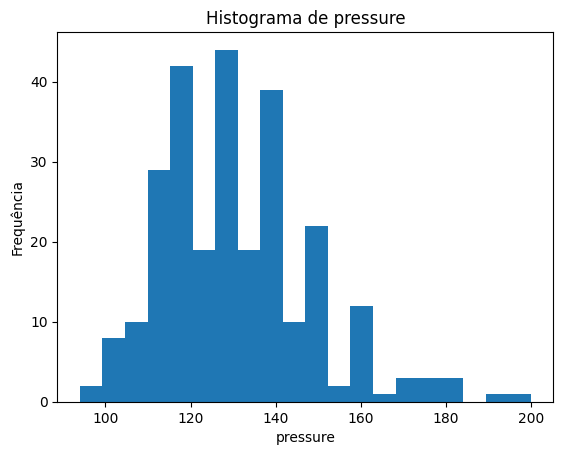

In [ ]:
import matplotlib.pyplot as plt

variaveis = ['age', 'cholestoral', 'pressure']

for var in variaveis:
    plt.figure()
    plt.hist(df[var], bins=20)
    plt.title(f'Histograma de {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência')
    plt.show()

**Boxplot das variáveis**

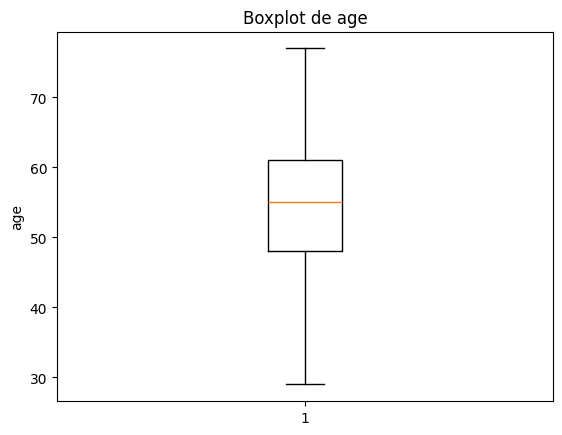

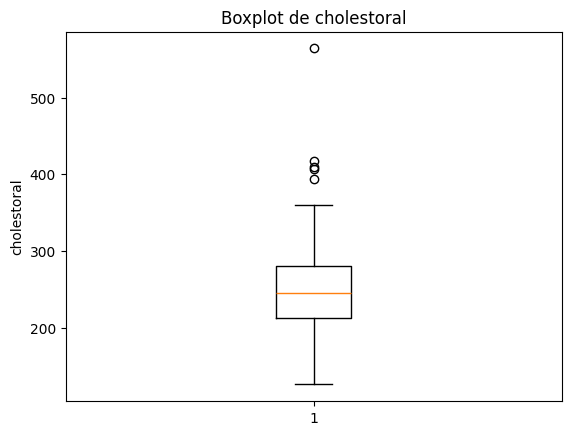

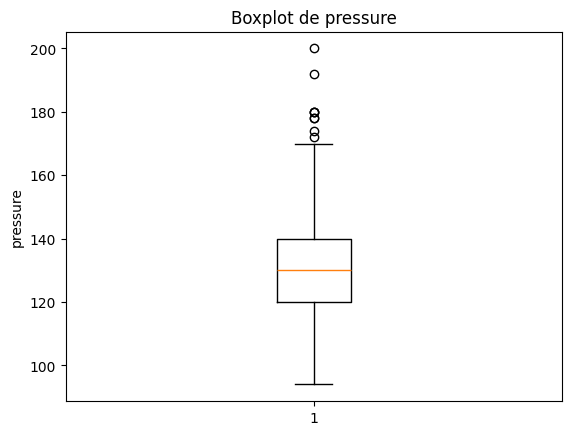

In [ ]:
for var in variaveis:
    plt.figure()
    plt.boxplot(df[var])
    plt.title(f'Boxplot de {var}')
    plt.ylabel(var)
    plt.show()

**Detecção de Outliers com Isolation Forest**

In [ ]:
from pyod.models.iforest import IForest

X = df[variaveis]

clf = IForest(contamination=0.05)  # 5% de outliers esperados
clf.fit(X)

# predição
outliers = clf.labels_   # 0 = normal, 1 = outlier

df['outlier'] = outliers

print(df['outlier'].value_counts())

outlier
0    256
1     14
Name: count, dtype: int64


**Idade vs Colesterol**

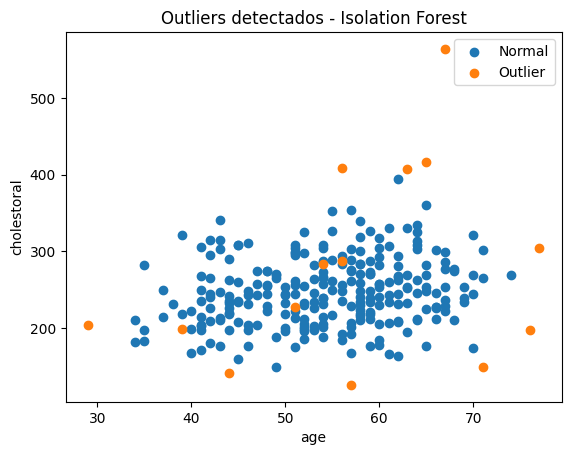

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df[df['outlier']==0]['age'],
            df[df['outlier']==0]['cholestoral'],
            label='Normal')

plt.scatter(df[df['outlier']==1]['age'],
            df[df['outlier']==1]['cholestoral'],
            label='Outlier')

plt.xlabel('age')
plt.ylabel('cholestoral')
plt.title('Outliers detectados - Isolation Forest')
plt.legend()

plt.show()

**Idade vs Pressão**

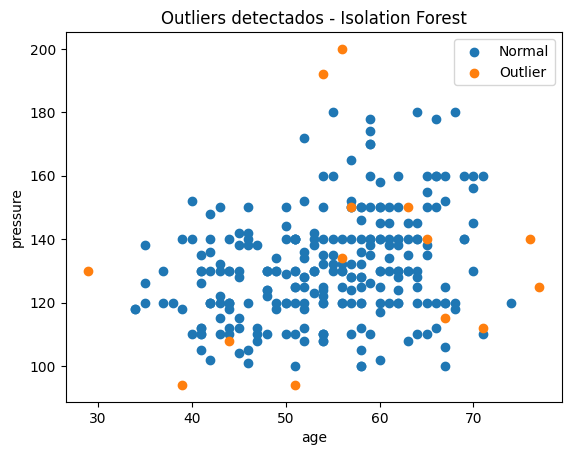

In [ ]:
plt.figure()

plt.scatter(df[df['outlier']==0]['age'],
            df[df['outlier']==0]['pressure'],
            label='Normal')

plt.scatter(df[df['outlier']==1]['age'],
            df[df['outlier']==1]['pressure'],
            label='Outlier')

plt.xlabel('age')
plt.ylabel('pressure')
plt.title('Outliers detectados - Isolation Forest')
plt.legend()

plt.show()

**Colesterol vs Pressão**

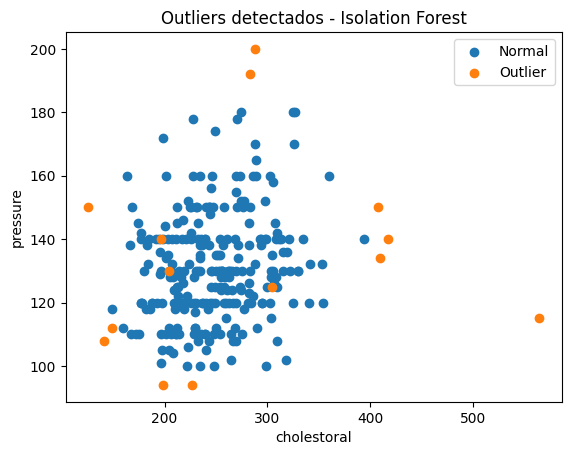

In [ ]:
plt.figure()

plt.scatter(df[df['outlier']==0]['cholestoral'],
            df[df['outlier']==0]['pressure'],
            label='Normal')

plt.scatter(df[df['outlier']==1]['cholestoral'],
            df[df['outlier']==1]['pressure'],
            label='Outlier')

plt.xlabel('cholestoral')
plt.ylabel('pressure')
plt.title('Outliers detectados - Isolation Forest')
plt.legend()

plt.show()

**Visualizar quais são os outliers**

In [ ]:
outliers_detectados = df[df['outlier'] == 1]

print(outliers_detectados[variaveis])

     age  cholestoral  pressure
5     63          407       150
52    56          288       200
65    54          283       192
82    56          409       134
88    77          304       125
120   67          564       115
128   71          149       112
148   65          417       140
153   57          126       150
161   76          197       140
164   39          199        94
177   44          141       108
238   29          204       130
241   51          227        94
